<a href="https://colab.research.google.com/github/Harsh-Prajapati54/NLP----/blob/main/Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Text Classification



In this notebook we are going too build an emotion detector of an human from the text they have written , we are going to classify ` anger, disgust, fear, joy, sadness, and surprise.` emotions of the humans

***our task will be to train a model that can classify it into one of these emotions.***

#### Installing compatible versions

In [ ]:
!pip install -q \
  "transformers==4.40.0" \
  "datasets==2.19.0" \
  "huggingface_hub==0.23.0" \
  "accelerate==0.29.0" \
  "scikit-learn" \
  "umap-learn" \
  "nltk"

In [ ]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")  # add token in Colab secrets 🔑

### Download Datasets
from HuggingFace

In [ ]:
from datasets import load_dataset

emotions = load_dataset("emotion")
print(emotions)

In [ ]:
emotions

In [ ]:
train_ds = emotions["train"]
train_ds

In [ ]:
len(train_ds)

In [ ]:
train_ds[0]

In [ ]:
train_ds.column_names

In [ ]:
print(train_ds.features)

Now lets convert this dictoniory based dataset into rows and column (tabular)

In [ ]:
import pandas as pd
emotions.set_format("pandas")
df = emotions["train"][:]

In [ ]:
df.head()

In [ ]:
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
df.head()

hence it is an classification problem lets check the distribution of data hence balanced and skwed dataset requires diffrent treatments for best result in model training

In [ ]:
import matplotlib.pyplot as plt

df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("distribution of class")

Transformer models like DistilBERT cannot receive raw strings as input; instead, they
assume the text has been tokenized and encoded as numerical vectors.

 ***Tokenization is the step of breaking down a string into the atomic units used in the model***

#### Character Tokenization

The simplest tokenization scheme is to feed each character individually to the model.

In [ ]:
text = "tokenization is the step of breaking down a string into the atomic units used in the model"
tokenized_text = list(text)
print(tokenized_text)

 Our model expects each character to be
converted to an integer, a process sometimes called `numericalization`.

In [ ]:
token_to_idx = {ch:idx for idx, ch in enumerate(sorted(set(tokenized_text)))}
print(token_to_idx)

this gives us a mapping from each character from sentence to a unique integer

In [ ]:
input_ids = [token_to_idx[token] for token in tokenized_text]
print(input_ids)

In [ ]:
categorical_df = pd.DataFrame(
{"Name": ["Bumblebee", "Optimus Prime", "Megatron"], "Label ID": [0,1,2]})
categorical_df

In [ ]:
pd.get_dummies(categorical_df["Name"],dtype = float)

In [ ]:
import torch
import torch.nn.functional as F
input_ids = torch.tensor(input_ids)
one_hot_encodings = F.one_hot(input_ids, num_classes=len(token_to_idx))
one_hot_encodings.shape

For each of the 90 input tokens we now have a one-hot vector with 22 dimensions,
since our vocabulary consists of 22 unique characters.

In [ ]:
print(f"Token : {tokenized_text[0]}")
print(f"Tensor index: {input_ids[0]}")
print(f"Vector : {one_hot_encodings[0]}")


From our simple example we can see that character-level tokenization ignores any
structure in the text and treats the whole string as a stream of characters. Although
this helps deal with misspellings and rare words, the main drawback is that linguistic
structures such as words need to be learned from the data.

#### Word Tokenization

Instead of splitting the text into the character , if we split by word then it is word tokenization

One simple class of word tokenizers uses whitespace to tokenize the text. We can do
this by applying Python’s split() function directly on the raw text

In [ ]:
tokenized_text = text.split()
print(tokenized_text)

Why large vocabularies are problematic:
A 1M-word vocabulary compressed to 1K dimensions in a neural network's first layer = 1 billion weights — comparable to GPT-2's entire parameter count. This makes models expensive to train and hard to maintain.

#### Subword Tokenization

The basic idea behind subword tokenization is to combine the best aspects of charac
ter and word tokenization. On the one hand, we want to split rare words into smaller
units to allow the model to deal with complex words and misspellings. On the other
hand, we want to keep frequent words as unique entities so that we can keep the
length of our inputs to a manageable size.

In [ ]:
from transformers import AutoTokenizer
model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [ ]:
from transformers import DistilBertTokenizer

distilbert_tokenizer = DistilBertTokenizer.from_pretrained(model_ckpt)


Let’s examine how this tokenizer works by feeding it our simple “Tokenizing text is a
core task of NLP.” example text

In [ ]:
encoded_text = tokenizer(text)
print(encoded_text)

Just as with character tokenization, we can see that the words have been mapped to
unique integers in the input_ids field Now that we have the input_ids, we can convert them back
into tokens by using the tokenizer’s convert_ids_to_tokens() method

In [ ]:
token = tokenizer.convert_ids_to_tokens(encoded_text["input_ids"])
print(token)

The AutoTokenizer class has a convert_tokens_to_string() method for
doing just that, so let’s apply it to our tokens:

In [ ]:
print(tokenizer.convert_tokens_to_string(token))

In [ ]:
tokenizer.vocab_size

####Tokenizing the Whole Dataset

In [ ]:
def tokenize(batch):
    return tokenizer(batch["text"].tolist(), padding=True, truncation=True)

print(tokenize(emotions["train"][:2]))

Here we can see the result of padding: the first element of input_ids is shorter than
the second, so zeros have been added to that element to make them the same length.
These zeros have a corresponding [PAD] token in the vocabulary, and the set of spe
cial tokens also includes the [CLS] and [SEP] tokens that we encountered earlier:

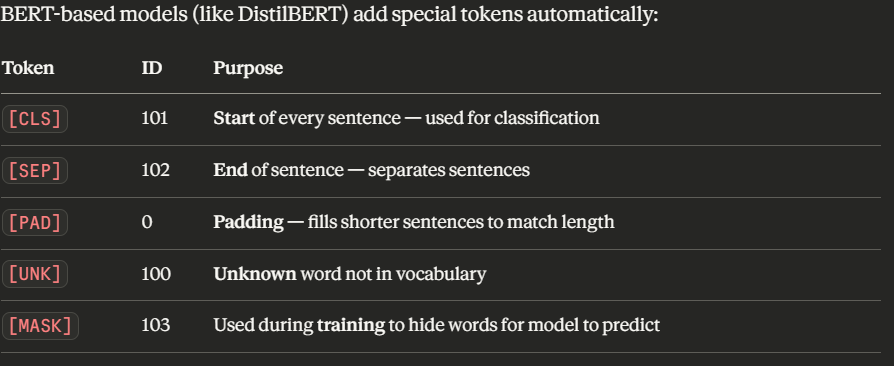

Once we’ve defined a processing function, we can apply it across all the splits in the
corpus in a single line of code:

In [ ]:
emotions_encoded = emotions.map(tokenize,batched=True,batch_size= None)

In [ ]:
print(emotions_encoded["train"].column_names)

### Training Classifier

DistilBERT is a smaller, faster, and cheaper version of the famous BERT (Bidirectional Encoder Representations from Transformers) model.

##### **Using pretrained models**

We will use another convenient auto class from  Transformers called AutoModel.
Similar to the AutoTokenizer class, AutoModel has a from_pretrained() method to
load the weights of a pretrained model. Let’s use this method to load the DistilBERT
checkpoint

In [ ]:
from transformers import AutoModel

model_ckpt = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(model_ckpt).to(device)

In [ ]:
text = "this is a test"
inputs = tokenizer(text, return_tensors="pt")
print(f"Input tensor shape: {inputs['input_ids'].size()}")

In [ ]:
inputs = {k:v.to(device) for k,v in inputs.items()}
with torch.no_grad():
  outputs = model(**inputs)
print(outputs)